
# **Diabetes Progression Prediction using Artificial Neural Network (ANN)**
---
---
## Module End Assignment 5 – Deep Learning
This project applies Deep Learning techniques to model the progression of diabetes using the Diabetes dataset available in sklearn.<br>
Exploratory Data Analysis is performed to understand feature distribution and relationships, followed by preprocessing steps such as scaling. An Artificial Neural Network (ANN) model is built, evaluated, and improved using hyperparameter tuning.

## 1. Importing Essential Libraries
___
Import essential libraries for data manipulation, visualization, preprocessing, and deep learning modeling.

In [2]:
# Importing essential libraries
#--------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Sklearn libraries
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Deep Learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

##2. Loading the dataset
---
The Diabetes dataset is loaded from sklearn.
The dataset contains 10 numerical medical predictor variables and one target variable representing disease progression.

In [3]:
# Load Diabetes dataset
#------------------------
diabetes = load_diabetes()

# Convert to DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['Progression'] = diabetes.target

# Display dataset
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


##3. Basic Data Inspection
---
Verify dataset shape, structure, data types, and statistical summary.

In [4]:
# Check dataset shape
#-----------------------
df.shape

(442, 11)

In [5]:
# Dataset information
#-----------------------
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          442 non-null    float64
 1   sex          442 non-null    float64
 2   bmi          442 non-null    float64
 3   bp           442 non-null    float64
 4   s1           442 non-null    float64
 5   s2           442 non-null    float64
 6   s3           442 non-null    float64
 7   s4           442 non-null    float64
 8   s5           442 non-null    float64
 9   s6           442 non-null    float64
 10  Progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
# Statistical summary
#-----------------------
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


The dataset contains only numerical features and no categorical variables.

##4. Exploratory Data Analysis (EDA)
---
EDA is performed to understand feature distributions, relationships, correlations, and influence on disease progression.

###4.1 Missing Value Check

In [7]:
# Missing value check
#------------------------
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


The dataset does not contain missing values, ensuring data completeness.

###4.2 Target Variable Analysis

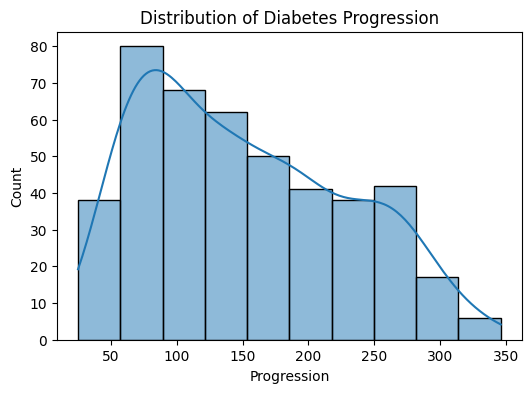

In [8]:
# Distribution of target variable
#------------------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['Progression'], kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

The target variable shows continuous distribution indicating a regression problem

###4.3 Univariate Analysis
Histograms help understand distribution and skewness of numerical features.

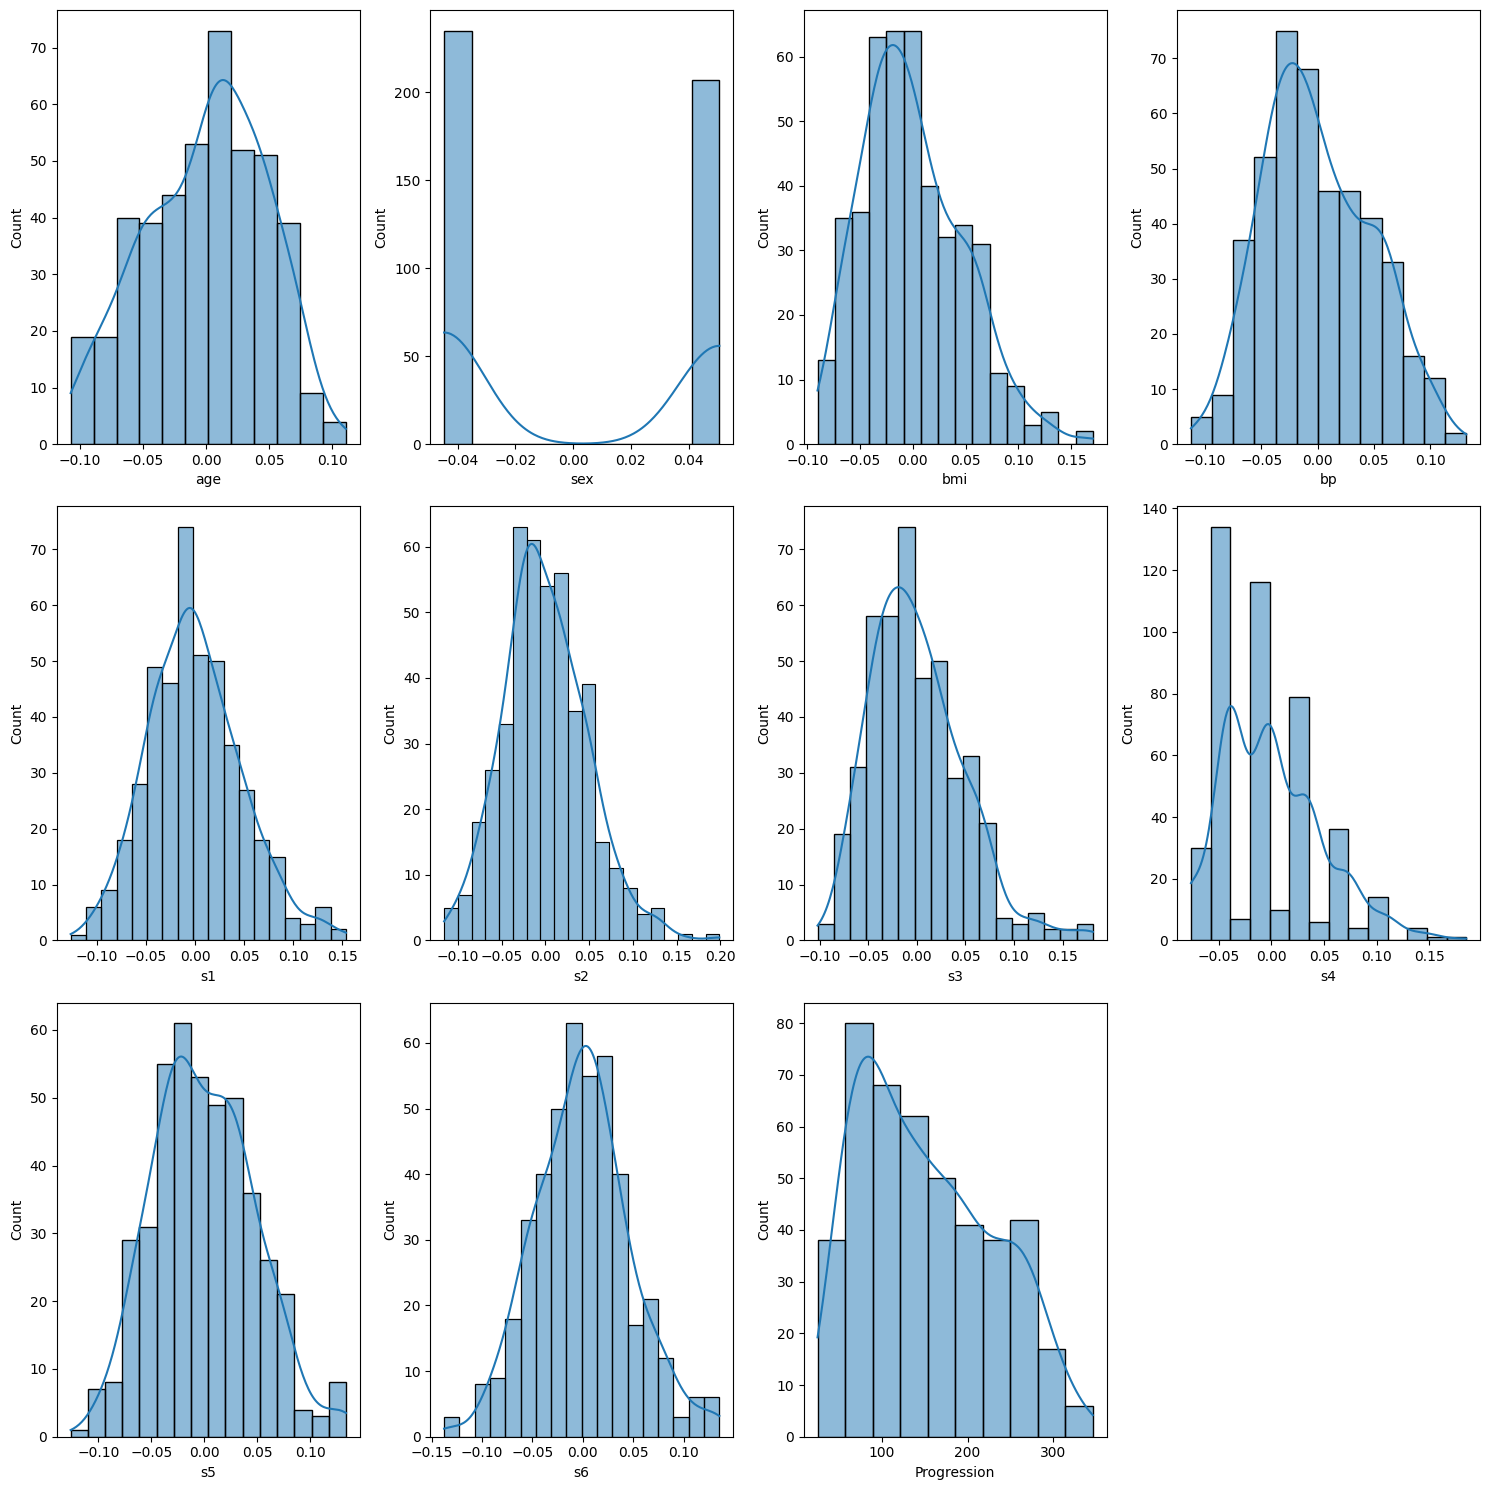

In [9]:
# Histogram for numerical features
#------------------------------------

n = df.select_dtypes(include='number')

n_cols = 4
n_rows = (len(n.columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(n.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Several features show slight skewness. Feature scaling is necessary before applying ANN.

###4.4 Correlation Analysis

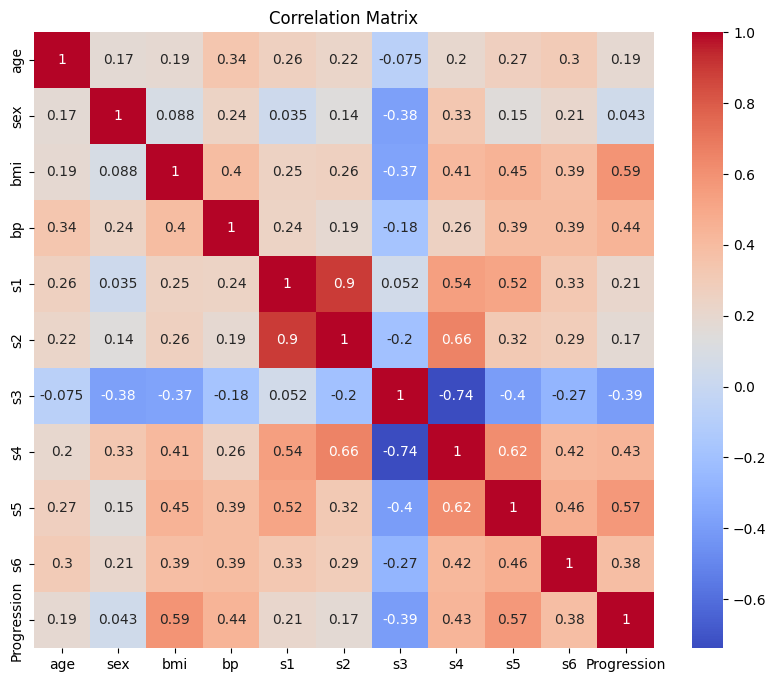

In [10]:
# Correlation Heatmap
#-----------------------
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Correlation analysis reveals moderate relationships between BMI, BP, and disease progression.

##5. Data Pre-processing
---
Preprocessing prepares the dataset for ANN modeling.

###5.1 Feature & Target Separation

In [11]:
# Feature & Target separation
#-------------------------------
x = df.drop('Progression', axis=1)
y = df['Progression']

###5.2 Feature Scaling
Scaling is essential for Neural Networks to ensure equal contribution of all features.

In [12]:
# Standardization using StandardScaler
#----------------------------------------
scaler = StandardScaler()
x = scaler.fit_transform(x)

###5.3 Train-Test Split

In [13]:
# Splitting dataset into training and testing
#-----------------------------------------------
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

##6. Model Building (Artificial Neural Network)
---
ANN is used to capture non-linear relationships between medical features and disease progression.

###6.1 Building Baseline ANN Model

In [15]:
# Initialize ANN model
#-------------------------
model = Sequential()

# Hidden layers
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu'))

# Output layer (Regression)
model.add(Dense(1, activation='linear'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

###6.2 Compiling the Model

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

###6.3 Training the Model

In [17]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 31374.7266 - mae: 158.0780 - val_loss: 22119.6367 - val_mae: 132.6592
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30870.1094 - mae: 156.4815 - val_loss: 21656.9648 - val_mae: 130.9046
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30188.5215 - mae: 154.2865 - val_loss: 21008.0762 - val_mae: 128.4396
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29137.0312 - mae: 150.9715 - val_loss: 20073.2148 - val_mae: 124.8858
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27595.0996 - mae: 146.0814 - val_loss: 18729.1504 - val_mae: 119.7841
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25363.5801 - mae: 138.9376 - val_loss: 16915.7188 - val_mae: 112.6847
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22324.4336 - mae: 128.7654 - val_loss: 14654.4805 - val_mae: 103.2486
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18623.7188 - mae: 115.6636 - val_loss

##7. Model Evaluation
---

In [19]:
# Predictions
#--------------
y_pred = model.predict(x_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Mean Squared Error: 2812.1023835692245
R2 Score: 0.46922955078503203


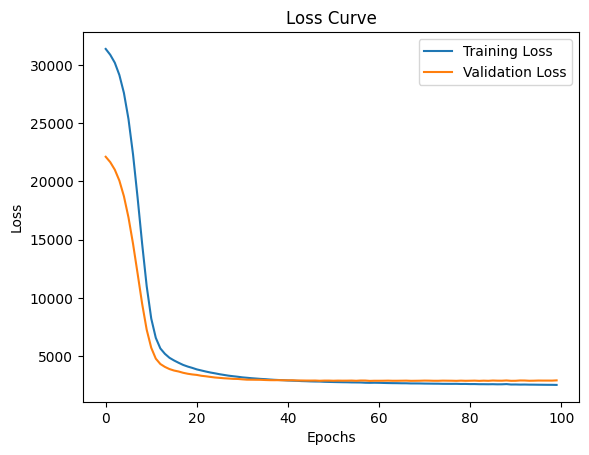

In [25]:
# Loss Curve Visualization
#--------------------------------

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

##8. Hyperparameter Tuning for Model Improvement
---
To improve performance:

- Increased number of neurons

- Added extra hidden layer

- Reduced learning rate

- Increased epochs

In [22]:
improved_model = Sequential()

improved_model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
improved_model.add(Dense(64, activation='relu'))
improved_model.add(Dense(32, activation='relu'))
improved_model.add(Dense(1, activation='linear'))

improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

history2 = improved_model.fit(
    x_train, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 31332.6562 - mae: 158.1138 - val_loss: 22184.2695 - val_mae: 133.0387
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30817.0352 - mae: 156.5864 - val_loss: 21645.6895 - val_mae: 131.1467
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29828.7832 - mae: 153.6258 - val_loss: 20638.0703 - val_mae: 127.5382
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27953.6055 - mae: 147.9176 - val_loss: 18776.7969 - val_mae: 120.6816
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24612.6875 - mae: 137.3524 - val_loss: 15810.8789 - val_mae: 108.9601
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 19590.4258 - mae: 119.9537 - val_loss: 11764.1338 - val_mae: 90.6951
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13461.4150 - mae: 94.9856 - val_loss: 7453.6084 - val_mae: 66.5848
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8159.6870 - mae: 69.1971 - val_loss: 4525

###Improved Model Evaluation

In [24]:
y_pred2 = improved_model.predict(x_test)

mse2 = mean_squared_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

print("Improved Model MSE:", mse2)
print("Improved Model R2:", r22)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Improved Model MSE: 2761.0866523793143
Improved Model R2: 0.4788585183215307


## Summary
---
The Diabetes dataset was analyzed to predict disease progression using an Artificial Neural Network (ANN). Exploratory Data Analysis revealed moderate correlations between medical features and the target variable, with no missing values present. Feature scaling was applied to ensure optimal ANN performance.

A baseline ANN model achieved an R² score of 0.4692. After hyperparameter tuning, the improved model achieved an R² score of 0.4789 with reduced Mean Squared Error, indicating better prediction accuracy.

Overall, the tuned ANN model demonstrated improved generalization and effectively captured non-linear relationships in the dataset, making it suitable for regression-based healthcare prediction tasks.